In [27]:
# environment_version = "6"
# MAGIC %md
# MAGIC # 04 — Exploratory Data Analysis | Member 2
# MAGIC ## 1. What I am doing
# MAGIC Analyse reported crime categories, class imbalance, time, geography, location context,
# MAGIC missingness and unusual observations. Produce figures, tables and a written handover.
# MAGIC ## 2. Why I am doing it
# MAGIC Identify evidence that helps Members 3 and 4 choose preprocessing and evaluation strategies.
# MAGIC The target is `primary_type`, a multiclass incident category, not whether crime will occur.
# MAGIC ## Run instructions
# MAGIC Attach Databricks Python compute with access to Member 1's cleaned table and **Run all**.
# MAGIC Change the widgets if your catalog/schema differs. No source table is modified.
# MAGIC `output_dir` may be a writable `/Volumes/<catalog>/<schema>/<volume>/member2` path.
# MAGIC The default evidence Volume persists after compute stops. If you change it to `/tmp`,
# MAGIC download the ZIP before stopping compute because that location is temporary.
# MAGIC Keep `features_table` empty until Member 3 supplies a table with `unique_key` and
# MAGIC `city_zone` or `area_group`. The optional table must match the same incident population.
# MAGIC Set `session_timezone` to the timezone that reproduces Member 1's source wall-clock dates.
# MAGIC UTC is the default for naive source timestamps ingested without conversion; do not shift
# MAGIC to America/Chicago unless Member 1 confirms the stored timestamps represent actual UTC instants.
# MAGIC EDA uses the full cleaned extract descriptively. Agree a split before using findings to tune
# MAGIC models; do not repeatedly inspect held-out test labels during feature selection.

In [28]:
from pathlib import Path
from datetime import datetime, timezone
import html
import json
import re
import shutil
import tempfile
import uuid
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Initialize Spark Session if not already active
if 'spark' not in globals() or spark is None:
    from pyspark.sql import SparkSession
    spark = SparkSession.builder.appName('04_EDA').master('local[*]').getOrCreate()

from pyspark.sql import functions as F

# Fallback for dbutils and displayHTML if running in local Jupyter
if 'dbutils' not in globals():
    class MockWidgets:
        def __init__(self):
            self._w = {}
        def text(self, name, default):
            if name not in self._w:
                self._w[name] = default
        def get(self, name):
            return self._w.get(name, '')
    class MockDBUtils:
        def __init__(self):
            self.widgets = MockWidgets()
    dbutils = MockDBUtils()

if 'displayHTML' not in globals():
    try:
        from IPython.display import display, HTML
        def displayHTML(content):
            display(HTML(content))
    except Exception:
        def displayHTML(content):
            print(content)

for name, default in {
    "clean_table": "workspace.default.chicago_crime_clean",
    "features_table": "",
    "output_dir": str((Path.cwd().resolve() / "reports" / "eda_evidence").as_posix()),
    "session_timezone": "UTC",
}.items():
    dbutils.widgets.text(name, default)

CLEAN_TABLE = dbutils.widgets.get("clean_table").strip()
FEATURES_TABLE = dbutils.widgets.get("features_table").strip()
try:
    spark.conf.set("spark.sql.session.timeZone", dbutils.widgets.get("session_timezone"))
except Exception:
    pass
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ") + "_" + uuid.uuid4().hex[:8]
OUT = Path(dbutils.widgets.get("output_dir")) / RUN_ID
OUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 220, "font.size": 10})
NOTES, TABLES, FIGURES = [], {}, []

def note(title, observation, implication, signal):
    """Show and preserve the three required explanations beneath each important chart."""
    item = {"title": title, "observation": observation, "implication": implication, "signal": signal}
    NOTES.append(item)
    displayHTML("<h3>" + html.escape(title) + "</h3>" + "".join(
        "<p><b>" + label + ":</b> " + html.escape(str(value)) + "</p>"
        for label, value in [("What it shows", observation), ("Why it matters", implication), ("Pattern / limitation", signal)]
    ))

def table(name, frame):
    TABLES[name] = frame.copy()
    frame.to_csv(OUT / (name + ".csv"), index=False)
    display(frame)
    return frame

def savefig(name, fig):
    fig.tight_layout()
    for suffix in ("png", "svg"):
        fig.savefig(OUT / (name + "." + suffix), bbox_inches="tight")
    FIGURES.append(name)
    display(fig)
    plt.close(fig)

def bars(name, frame, label, value="count", title=None, top=None):
    view = frame.head(top) if top else frame
    fig, ax = plt.subplots(figsize=(10, max(4, len(view) * .25)))
    ax.barh(view[label].astype(str)[::-1], view[value][::-1], color="#236b8e")
    ax.set(title=title or name.replace("_", " "), xlabel=value.replace("_", " "))
    ax.grid(axis="x", alpha=.2)
    savefig(name, fig)

def heatmap(name, frame, row, column, value, title):
    pivot = frame.pivot(index=row, columns=column, values=value).fillna(0)
    fig, ax = plt.subplots(figsize=(12, max(4, len(pivot) * .4)))
    im = ax.imshow(pivot.to_numpy(dtype=float), aspect="auto", cmap="YlGnBu")
    ax.set_xticks(range(len(pivot.columns)), pivot.columns.astype(str), rotation=90)
    ax.set_yticks(range(len(pivot.index)), pivot.index.astype(str))
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label=value.replace("_", " "))
    savefig(name, fig)


## 3. Code / analysis — input contract and coverage
Read only the cleaned table. Derive temporary time fields for EDA; Member 3 owns the
reusable modelling transformations. Missing coordinates stay missing, and their records
remain in all non-coordinate analyses. Counts below refer to reported records, not population risk.

In [29]:
# Robust table loading (Databricks delta table or local CSV fallback)
SOURCE_VERSION = 1

def locate_file(rel_path):
    curr = Path.cwd().resolve()
    for p in [curr] + list(curr.parents):
        candidate = p / rel_path
        if candidate.exists():
            return str(candidate).replace('\\', '/')
    direct = Path('D:/Projects/Chicago_Crime_Prediction') / rel_path
    if direct.exists():
        return str(direct).replace('\\', '/')
    return str(curr / rel_path).replace('\\', '/')

try:
    SOURCE_VERSION = int(spark.sql(f"DESCRIBE HISTORY {CLEAN_TABLE}").select("version").first()["version"])
    df = spark.read.option("versionAsOf", SOURCE_VERSION).table(CLEAN_TABLE)
except Exception:
    # Local fallback: temp view or local clean/raw CSV
    try:
        df = spark.table("chicago_crime_clean")
    except Exception:
        clean_csv = locate_file('data/clean/chicago_crime_clean.csv')
        if not Path(clean_csv).exists():
            clean_csv = locate_file('data/raw/chicago_crime_raw.csv')
        df = spark.read.option("header", "true").option("inferSchema", "true").csv(clean_csv)
        df.createOrReplaceTempView("chicago_crime_clean")

required = {"unique_key", "date", "primary_type", "district", "community_area", "ward",
            "beat", "latitude", "longitude", "location_description", "domestic"}
missing = sorted(required - set(df.columns))
if missing:
    raise ValueError(f"Clean table is missing required columns: {missing}")

# Ensure date is timestamp type
if dict(df.dtypes)["date"] not in ("timestamp", "timestamp_ntz", "date"):
    df = df.withColumn("date", F.to_timestamp("date"))

meta = df.agg(F.count("*").alias("rows"), F.min("date").alias("start"),
              F.max("date").alias("end"),
              F.sum(F.col("date").isNull().cast("long")).alias("null_dates"),
              F.sum((F.col("primary_type").isNull() | (F.trim("primary_type") == "")).cast("long")).alias("null_targets")).first().asDict()
N = meta["rows"]
if N == 0 or meta["null_dates"] or meta["null_targets"]:
    raise ValueError(f"Input needs Member 1 review before EDA: {meta}")
display(pd.DataFrame([meta]))
eda = (df.withColumn("eda_year", F.year("date"))
       .withColumn("eda_month", F.month("date"))
       .withColumn("eda_hour", F.hour("date"))
       .withColumn("eda_day", F.to_date("date"))
       .withColumn("eda_weekday", F.pmod(F.dayofweek("date") + F.lit(5), F.lit(7))))
START, END = pd.Timestamp(meta["start"]), pd.Timestamp(meta["end"])
calendar = pd.DataFrame({"day": pd.date_range(START.normalize(), END.normalize(), freq="D")})
calendar["eda_weekday"] = calendar.day.dt.dayofweek


{"ts": "2026-10-06 13:38:41.749", "level": "ERROR", "logger": "SQLQueryContextLogger", "msg": "[TABLE_OR_VIEW_NOT_FOUND] The table or view `HISTORY` cannot be found. Verify the spelling and correctness of the schema and catalog.\nSearch path: [`system`.`builtin`, `system`.`session`, `spark_catalog`.`default`].\nIf you did not qualify the name with a schema, verify the current_schema() output, or qualify the name with the correct schema and catalog.\nTo tolerate the error on drop use DROP VIEW IF EXISTS or DROP TABLE IF EXISTS. SQLSTATE: 42P01", "context": {"errorClass": "TABLE_OR_VIEW_NOT_FOUND"}, "exception": {"class": "Py4JJavaError", "msg": "An error occurred while calling o28.sql.\n: org.apache.spark.sql.AnalysisException: [TABLE_OR_VIEW_NOT_FOUND] The table or view `HISTORY` cannot be found. Verify the spelling and correctness of the schema and catalog.\nSearch path: [`system`.`builtin`, `system`.`session`, `spark_catalog`.`default`].\nIf you did not qualify the name with a schema

,rows,start,end,null_dates,null_targets
0,662472,2024-01-01 05:30:00,2026-09-16 05:30:00,0,0


### Target distribution and class imbalance
Use every class, including rare classes. The majority-class share is a descriptive constant-
predictor accuracy reference on this extract; it is not an independently evaluated model score.

d:\Projects\Chicago_Crime_Prediction\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,primary_type,count,share_pct,cumulative_pct
0,THEFT,151279,22.835531,22.835531
1,BATTERY,119221,17.996383,40.831914
2,CRIMINAL DAMAGE,72871,10.999861,51.831776
3,ASSAULT,60026,9.060911,60.892687
4,MOTOR VEHICLE THEFT,51942,7.840633,68.733320
5,OTHER OFFENSE,45088,6.806023,75.539344
6,DECEPTIVE PRACTICE,41133,6.209017,81.748361
7,BURGLARY,28010,4.228103,85.976464
8,ROBBERY,18328,2.766607,88.743071
9,NARCOTICS,18068,2.727361,91.470432


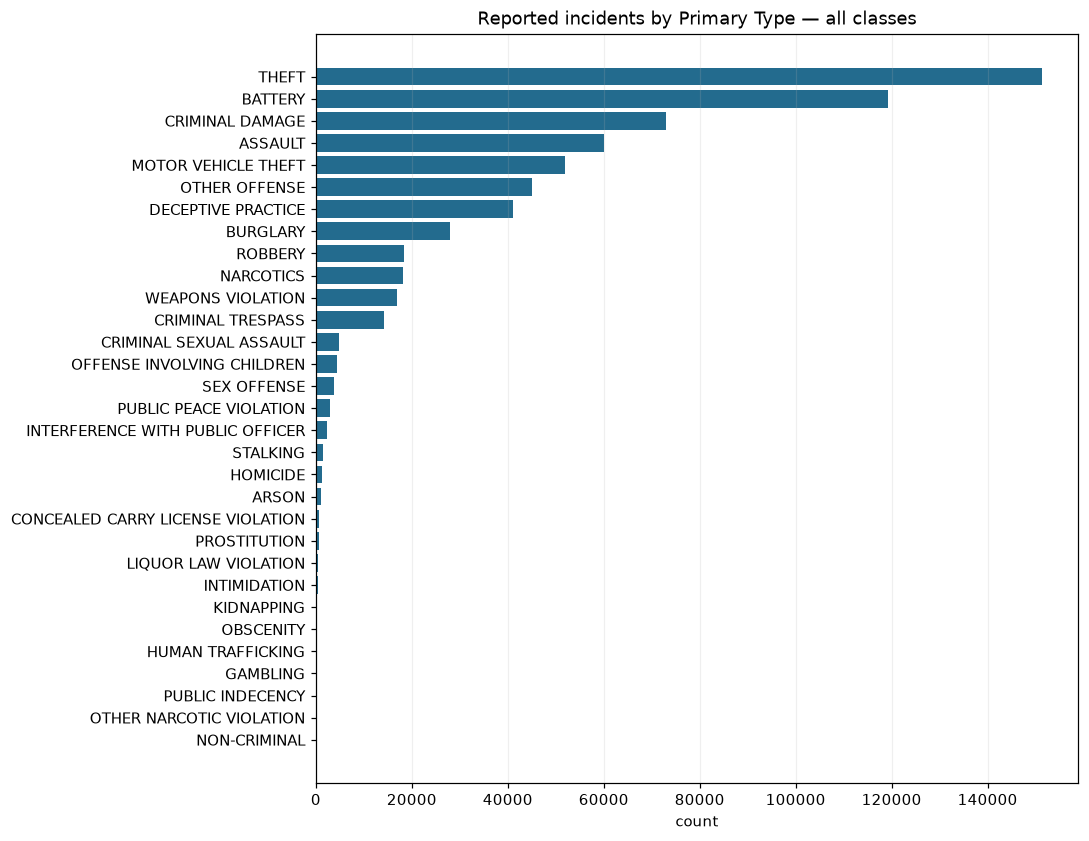

,classes,largest_class,smallest_class,largest_smallest_ratio,majority_share_pct,classes_below_100,top_5_share_pct
0,31,THEFT,NON-CRIMINAL,16808.777778,22.835531,5,68.73332


In [30]:
classes = eda.groupBy("primary_type").count().toPandas().sort_values(["count", "primary_type"], ascending=[False, True]).reset_index(drop=True)
classes["share_pct"] = classes["count"] / N * 100
classes["cumulative_pct"] = classes.share_pct.cumsum()
table("class_distribution", classes)
bars("01_primary_type", classes, "primary_type", title="Reported incidents by Primary Type — all classes")
major, minor = classes.iloc[0], classes.iloc[-1]
imbalance = {"classes": len(classes), "largest_class": major.primary_type,
             "smallest_class": minor.primary_type, "largest_smallest_ratio": float(major["count"] / minor["count"]),
             "majority_share_pct": float(major.share_pct), "classes_below_100": int((classes["count"] < 100).sum()),
             "top_5_share_pct": float(classes.head(5).share_pct.sum())}
table("class_imbalance_summary", pd.DataFrame([imbalance]))
note("Class imbalance", f"{len(classes)} classes; {major.primary_type} has {major['count']:,} records ({major.share_pct:.2f}%). "
     f"{minor.primary_type} has {minor['count']:,}; largest/smallest ratio = {imbalance['largest_smallest_ratio']:.1f}. "
     f"{imbalance['classes_below_100']} classes have fewer than 100 records.",
     "Members 3/4: preserve rare-class support information; compare macro F1, macro precision/recall, weighted F1 and per-class recall. Fit any balancing on training data only.",
     "Class imbalance; accuracy can hide poor minority-class performance. Do not merge target classes merely to improve scores.")
TOP_TYPES = classes.head(5).primary_type.tolist()

### Temporal trends and incomplete-year comparisons
Yearly totals have different exposure when the extract starts/ends mid-year. The additional
matched-window chart uses the same month/day interval in every represented year and excludes
the last observed day conservatively. Month totals flag boundary months. Daily spike checks
include zero-record calendar days; a zero can also indicate a gap in ingestion.

d:\Projects\Chicago_Crime_Prediction\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
d:\Projects\Chicago_Crime_Prediction\.venv\Lib\site-packages\pyspark\sql\pandas\types.py:778: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,eda_year,count,first_record,last_record,calendar_boundary_coverage
1,2024,259631,2024-01-01,2024-12-31 23:58:00,Jan 1–Dec 31 endpoints
0,2025,238083,2025-01-01,2025-12-31 23:58:00,Jan 1–Dec 31 endpoints
2,2026,164758,2026-01-01,2026-09-16 00:00:00,Partial calendar year


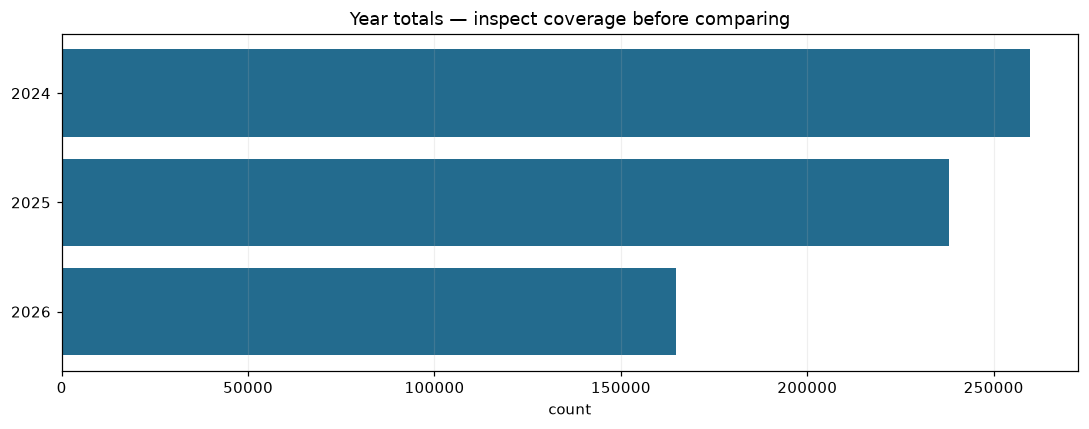

d:\Projects\Chicago_Crime_Prediction\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,eda_year,count
1,2024,186371
0,2025,170718
2,2026,164736


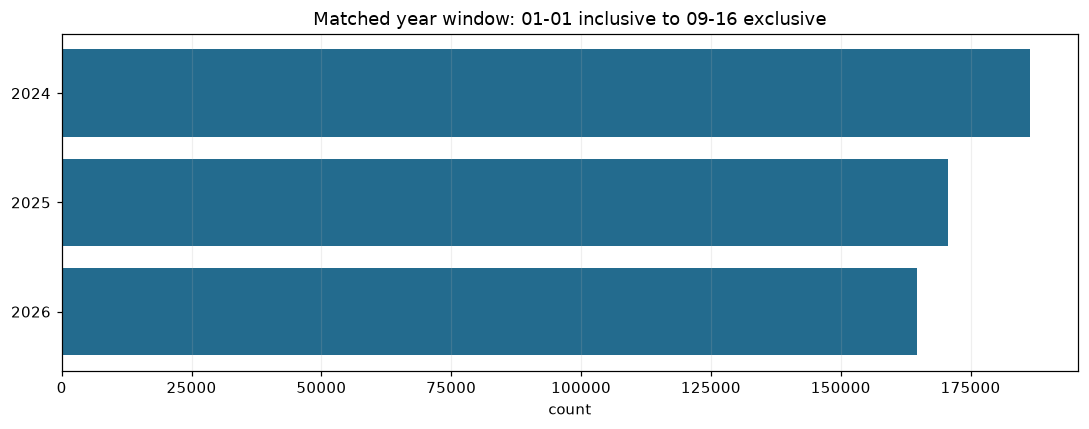

d:\Projects\Chicago_Crime_Prediction\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,month,count,boundary_month
0,2024-01,19713,True
1,2024-02,19988,False
2,2024-03,20954,False
3,2024-04,20534,False
4,2024-05,23031,False
5,2024-06,23246,False
6,2024-07,24149,False
7,2024-08,23046,False
8,2024-09,23030,False
9,2024-10,22522,False


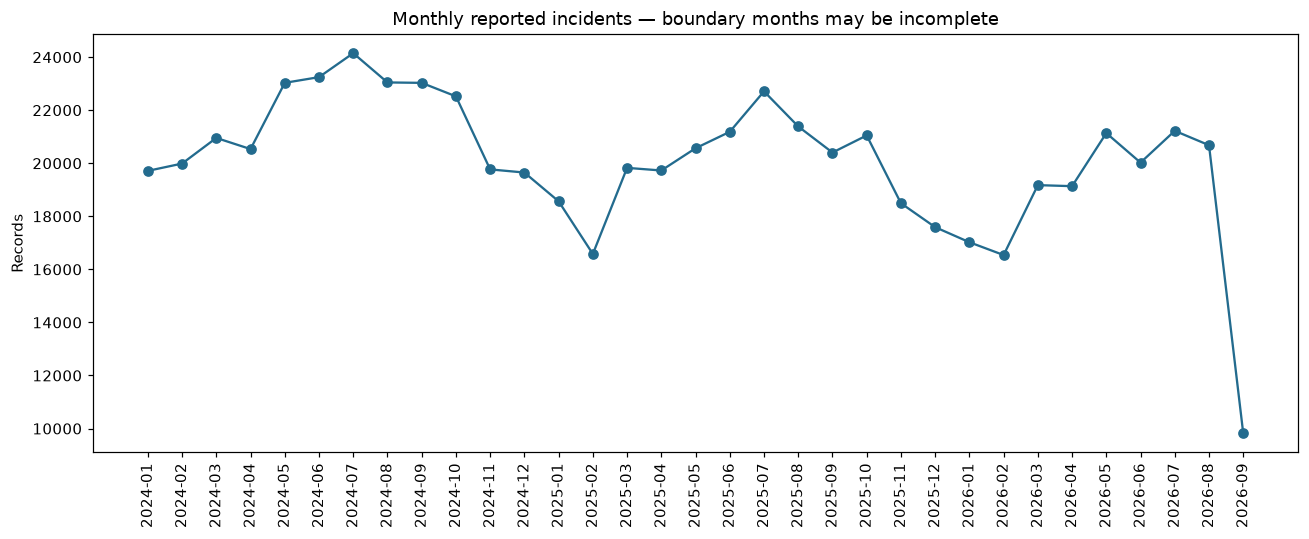

d:\Projects\Chicago_Crime_Prediction\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,eda_hour,count
0,0,45749
1,1,21890
2,2,19555
3,3,17458
4,4,14233
5,5,12317
6,6,13159
7,7,17034
8,8,22959
9,9,27413


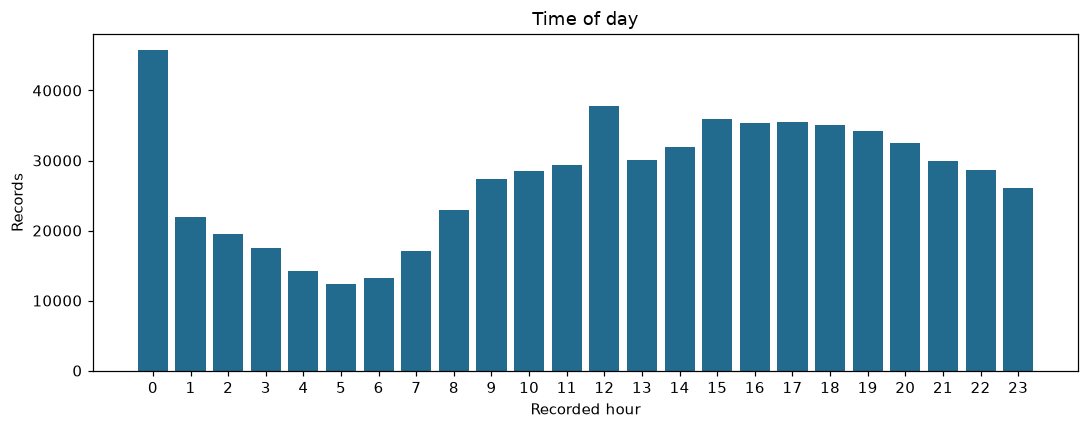

d:\Projects\Chicago_Crime_Prediction\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,eda_weekday,count,observed_calendar_days,records_per_calendar_day,weekday
0,0,95652,142,673.605634,Monday
1,1,93316,142,657.154930,Tuesday
2,2,93523,142,658.612676,Wednesday
3,3,92665,141,657.198582,Thursday
4,4,96975,141,687.765957,Friday
5,5,96198,141,682.255319,Saturday
6,6,94143,141,667.680851,Sunday


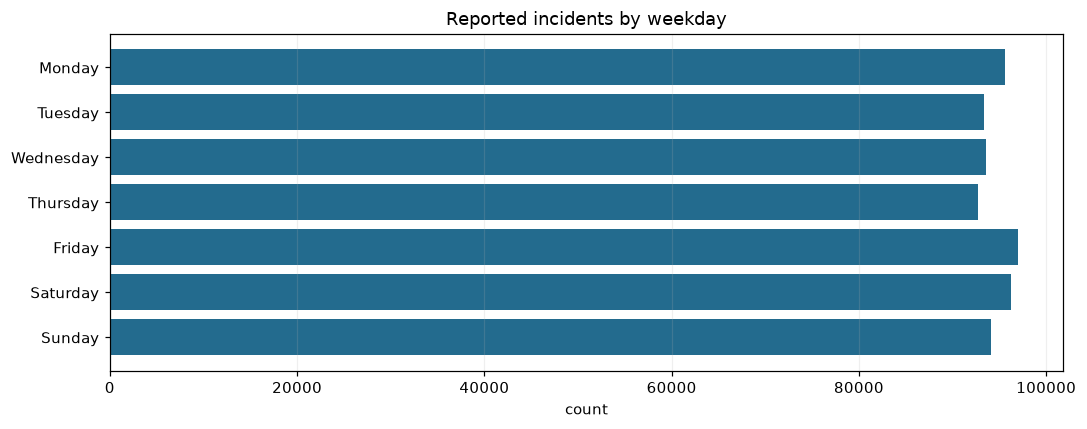

In [31]:
yearly = eda.groupBy("eda_year").agg(F.count("*").alias("count"), F.min("date").alias("first_record"), F.max("date").alias("last_record")).toPandas().sort_values("eda_year")
yearly["calendar_boundary_coverage"] = [
    "Jan 1–Dec 31 endpoints" if pd.Timestamp(a).strftime("%m-%d") == "01-01" and pd.Timestamp(b).strftime("%m-%d") == "12-31" else "Partial calendar year"
    for a, b in zip(yearly.first_record, yearly.last_record)]
table("yearly_counts", yearly)
bars("02_yearly_counts", yearly, "eda_year", title="Year totals — inspect coverage before comparing")
note("Yearly coverage", f"Observed dates: {START} to {END}. Year totals: " + "; ".join(f"{r.eda_year}: {r.count:,}" for r in yearly.itertuples()),
     "Compare equal date windows before interpreting year-to-year change; retain a time-aware validation strategy.",
     "Unequal exposure; endpoint coverage does not establish that every report was captured.")

lower_md = max(pd.Timestamp(v).strftime("%m-%d") for v in yearly.first_record)
upper_md = min(pd.Timestamp(v).strftime("%m-%d") for v in yearly.last_record)
matched = (eda.filter((F.date_format("date", "MM-dd") >= lower_md) & (F.date_format("date", "MM-dd") < upper_md))
           .groupBy("eda_year").count().toPandas().sort_values("eda_year"))
if not matched.empty:
    table("matched_calendar_window", matched)
    bars("03_matched_years", matched, "eda_year", title=f"Matched year window: {lower_md} inclusive to {upper_md} exclusive")
    note("Comparable yearly window", f"Counts use {lower_md} ≤ month/day < {upper_md} in every year; the upper boundary day is excluded.",
         "Use these totals instead of full-year versus year-to-date totals. Leap years may add one exposure day.",
         "Temporal comparison; reporting delay and later revisions still affect comparability.")
else:
    note("Comparable yearly window", "No shared non-empty calendar window is available.", "Do not infer annual change from unequal windows.", "Insufficient comparable coverage.")

monthly = eda.groupBy(F.date_format("date", "yyyy-MM").alias("month")).count().toPandas()
month_axis = pd.DataFrame({"month": pd.period_range(START, END, freq="M").astype(str)})
monthly = month_axis.merge(monthly, on="month", how="left").fillna({"count": 0})
monthly["boundary_month"] = monthly.month.isin([START.strftime("%Y-%m"), END.strftime("%Y-%m")])
table("monthly_counts", monthly)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly.month, monthly["count"], marker="o", color="#236b8e")
ax.tick_params(axis="x", rotation=90)
ax.set(title="Monthly reported incidents — boundary months may be incomplete", ylabel="Records")
savefig("04_monthly_trend", fig)
peak_month = monthly.loc[monthly["count"].idxmax()]
note("Monthly trend", f"The highest observed monthly total is {peak_month.month}: {int(peak_month['count']):,} records.",
     "Member 3: assess month as a candidate feature using training/validation data; inspect boundary months separately.",
     "Possible seasonality or reporting changes; a short series does not establish a recurring seasonal effect.")

hourly = pd.DataFrame({"eda_hour": range(24)}).merge(eda.groupBy("eda_hour").count().toPandas(), how="left", on="eda_hour").fillna(0)
table("hourly_counts", hourly)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(hourly.eda_hour, hourly["count"], color="#236b8e")
ax.set(xticks=range(24), xlabel="Recorded hour", ylabel="Records", title="Time of day")
savefig("05_hourly_counts", fig)
peak_hour = int(hourly.loc[hourly["count"].idxmax(), "eda_hour"])
note("Hour of day", f"The highest recorded-hour count occurs at {peak_hour:02d}:00.",
     "Evaluate hour (possibly cyclic encoding) on training/validation data and confirm timestamp semantics with Member 1.",
     "Temporal pattern; rounded/default incident times can create artificial peaks.")

week = pd.DataFrame({"eda_weekday": range(7)}).merge(eda.groupBy("eda_weekday").count().toPandas(), on="eda_weekday", how="left").fillna(0)
week = week.merge(calendar.groupby("eda_weekday").size().rename("observed_calendar_days"), on="eda_weekday", how="left")
week["records_per_calendar_day"] = week["count"] / week.observed_calendar_days
week["weekday"] = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
table("weekday_counts", week)
bars("06_weekday_counts", week, "weekday", title="Reported incidents by weekday")
note("Day of week", f"The largest weekday total is {week.loc[week['count'].idxmax(), 'weekday']}. CSV also includes records per calendar day of exposure.",
     "Member 3: evaluate weekday/weekend features; compare exposure-normalized counts when windows are short.",
     "Weekly pattern; first/last days may have incomplete hourly coverage.")

### Geographic counts and coordinate coverage
Administrative codes are categories, not continuous distances. Null codes remain an explicit
missing group. Coordinate bins are a visualization grid, not official City Zones. No incident
coordinates are collected to the driver; only aggregated bins are plotted.

d:\Projects\Chicago_Crime_Prediction\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,district,count
4,8,42717
21,12,42159
12,6,37810
17,1,37702
20,4,35868
9,18,35590
13,19,35539
2,11,35490
3,3,35143
23,2,35108


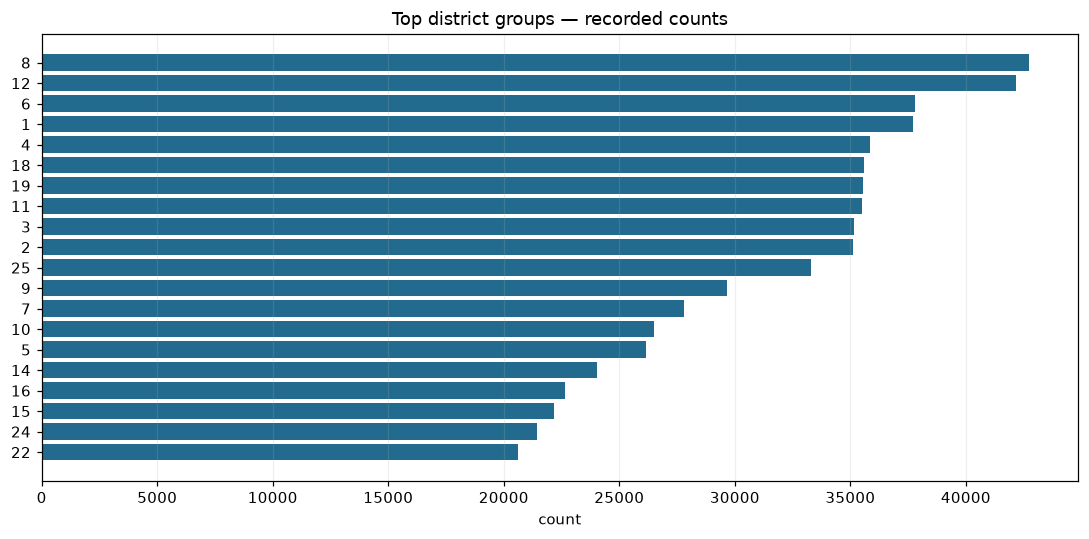

d:\Projects\Chicago_Crime_Prediction\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,community_area,count
44,25,33124
14,8,29984
16,28,28734
53,32,23553
22,43,22551
...,...,...
72,74,1424
66,12,1220
25,[MISSING],932
21,47,745


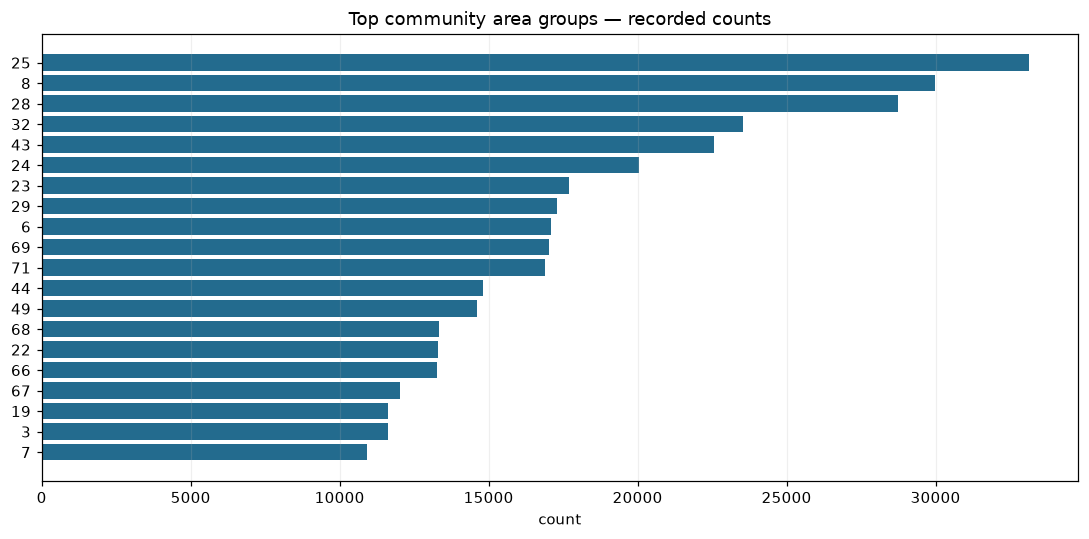

d:\Projects\Chicago_Crime_Prediction\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,ward,count
19,27,31090
9,28,29364
23,6,24727
4,42,23601
33,24,22641
37,20,22000
42,4,21591
20,17,20889
12,16,20188
47,21,19918


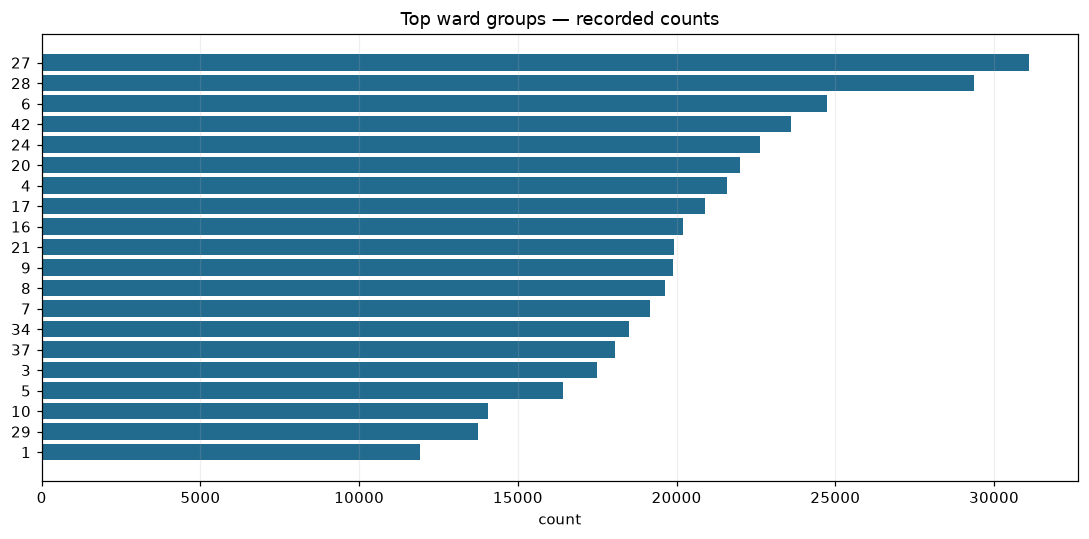

d:\Projects\Chicago_Crime_Prediction\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,beat,count
90,1834,8050
242,123,5422
122,1831,5030
75,421,4966
199,624,4448
...,...,...
139,1621,670
42,1655,512
198,1653,387
97,1652,154


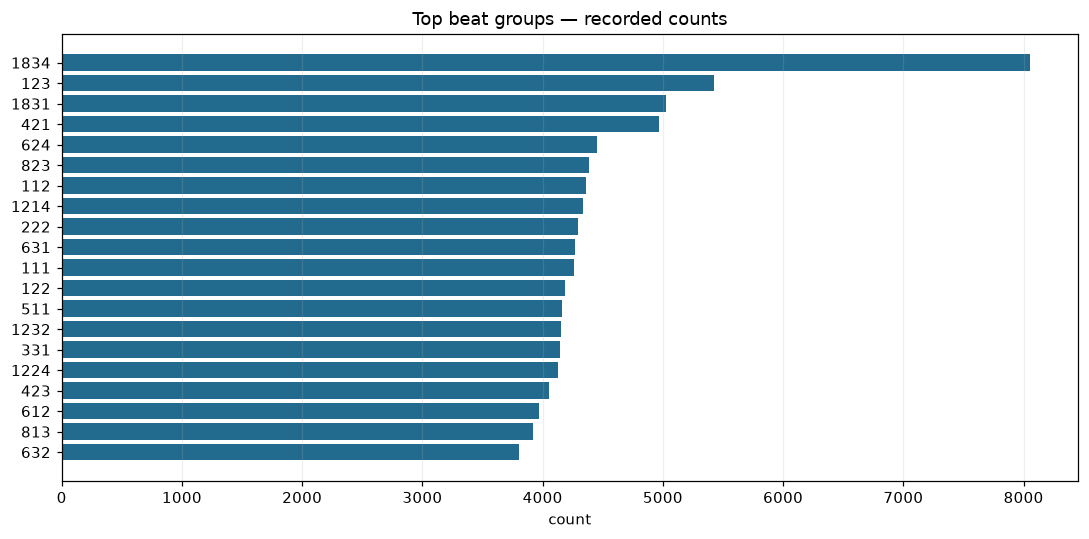

,column,missing_count,missing_pct
20,longitude,4435,0.669462
15,x_coordinate,4435,0.669462
21,location,4435,0.669462
16,y_coordinate,4435,0.669462
19,latitude,4435,0.669462
7,location_description,3145,0.474737
13,community_area,932,0.140685
12,ward,916,0.138270
5,primary_type,0,0.000000
4,iucr,0,0.000000


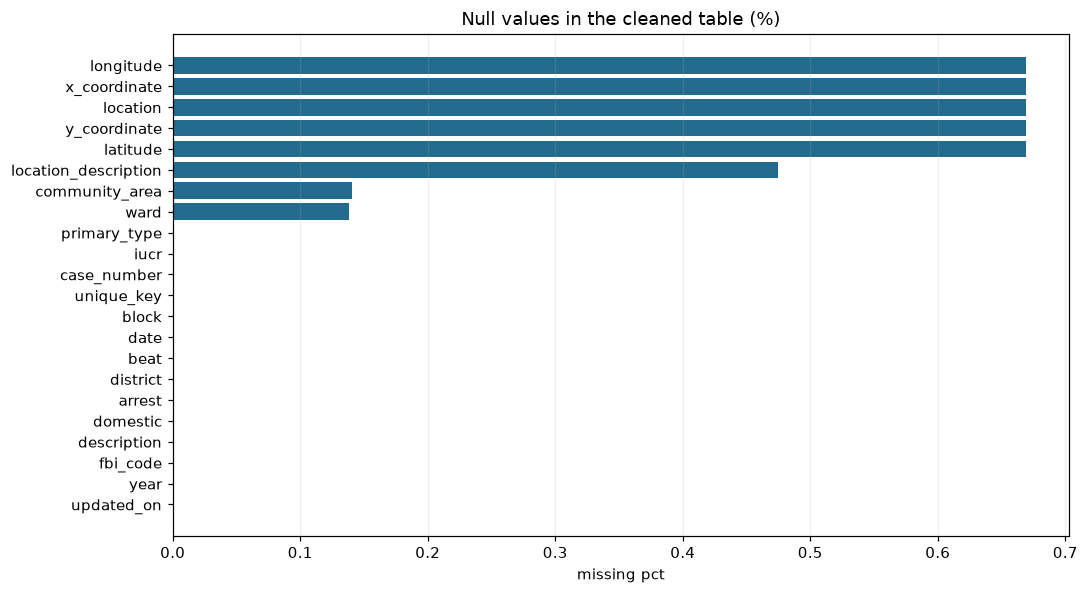

d:\Projects\Chicago_Crime_Prediction\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,coordinate_status,count
0,within_broad_screen,658037
1,missing_or_nan,4435


d:\Projects\Chicago_Crime_Prediction\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,primary_type,coordinate_status,count,within_class_pct
0,PUBLIC PEACE VIOLATION,missing_or_nan,18,0.600601
1,CRIMINAL SEXUAL ASSAULT,missing_or_nan,426,8.825357
2,PROSTITUTION,within_broad_screen,591,98.664441
3,STALKING,within_broad_screen,1528,98.963731
4,SEX OFFENSE,missing_or_nan,203,5.452592
5,OFFENSE INVOLVING CHILDREN,within_broad_screen,4256,94.493783
6,MOTOR VEHICLE THEFT,within_broad_screen,51775,99.678488
7,PUBLIC INDECENCY,within_broad_screen,37,100.000000
8,BURGLARY,missing_or_nan,100,0.357015
9,PROSTITUTION,missing_or_nan,8,1.335559


d:\Projects\Chicago_Crime_Prediction\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,lat_bin,lon_bin,count
0,4181,-8761,2504
1,4200,-8770,710
2,4192,-8766,1099
3,4201,-8778,29
4,4195,-8773,900
...,...,...,...
717,4196,-8788,2
718,4165,-8758,3
719,4198,-8786,1
720,4167,-8759,2


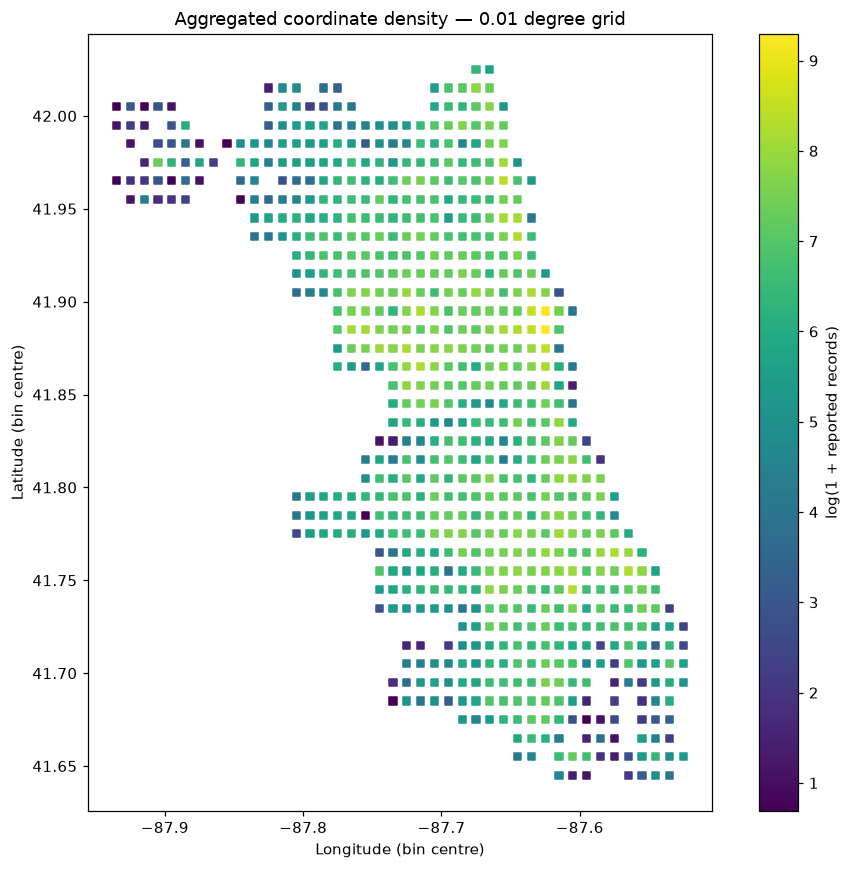

In [32]:
geography = {}
for field in ("district", "community_area", "ward", "beat"):
    counts = (eda.groupBy(F.coalesce(F.col(field).cast("string"), F.lit("[MISSING]")).alias(field))
              .count().toPandas().sort_values(["count", field], ascending=[False, True]))
    geography[field] = table(field + "_counts", counts)
    bars("07_" + field, counts, field, title=f"Top {field.replace('_', ' ')} groups — recorded counts", top=20)
    lead = counts.iloc[0]
    note(field.replace("_", " ").title(), f"Largest observed group: {lead[field]} ({lead['count']:,} records). All groups are in the CSV; chart shows at most 20.",
         "Member 3: treat codes categorically, allow missing/unseen values, and inspect sparse categories before encoding.",
         "Geographic count pattern; without population/exposure denominators these are not crime rates or measures of individual risk.")

null_row = df.agg(*[F.sum(F.col(c).isNull().cast("long")).alias(c) for c in df.columns]).first().asDict()
nulls = pd.DataFrame([{"column": c, "missing_count": n, "missing_pct": n / N * 100} for c, n in null_row.items()]).sort_values("missing_count", ascending=False)
table("missing_values", nulls)
bars("08_missing_values", nulls, "column", "missing_pct", "Null values in the cleaned table (%)")
note("Missing values", f"The highest null share is {nulls.iloc[0]['column']}: {nulls.iloc[0].missing_pct:.3f}%.",
     "Retain missingness indicators where justified; learn any model imputation from training data only. Never invent coordinates.",
     "Missingness; this chart counts SQL nulls, with NaN/invalid coordinates checked separately below.")

lat, lon = F.col("latitude"), F.col("longitude")
coord_missing = lat.isNull() | lon.isNull() | F.isnan(lat) | F.isnan(lon)
coord_valid = (~coord_missing) & lat.between(-90, 90) & lon.between(-180, 180)
# Broad screening window used by Member 1; not an official Chicago boundary.
coord_screen = coord_valid & lat.between(41, 43) & lon.between(-89, -87)
eda = eda.withColumn("coordinate_status", F.when(coord_missing, "missing_or_nan")
                     .when(~coord_valid, "invalid_global_range")
                     .when(~coord_screen, "outside_broad_screen").otherwise("within_broad_screen"))
coord_summary = table("coordinate_coverage", eda.groupBy("coordinate_status").count().toPandas())
coord_by_class = eda.groupBy("primary_type", "coordinate_status").count().toPandas()
coord_by_class["within_class_pct"] = coord_by_class["count"] / coord_by_class.groupby("primary_type")["count"].transform("sum") * 100
table("coordinate_coverage_by_class", coord_by_class)
grid = (eda.filter(F.col("coordinate_status") == "within_broad_screen")
        .groupBy(F.floor(lat / .01).alias("lat_bin"), F.floor(lon / .01).alias("lon_bin"))
        .count().toPandas())
table("coordinate_grid", grid)
if not grid.empty:
    fig, ax = plt.subplots(figsize=(9, 8))
    points = ax.scatter((grid.lon_bin + .5) * .01, (grid.lat_bin + .5) * .01,
                        c=np.log1p(grid["count"]), s=22, marker="s", cmap="viridis")
    ax.set(xlabel="Longitude (bin centre)", ylabel="Latitude (bin centre)", title="Aggregated coordinate density — 0.01 degree grid")
    ax.set_aspect(1 / np.cos(np.deg2rad(41.88)))
    fig.colorbar(points, ax=ax, label="log(1 + reported records)")
    savefig("09_coordinate_density", fig)
mapped = int(grid["count"].sum()) if not grid.empty else 0
note("Coordinate coverage and spatial density", f"{mapped:,}/{N:,} records ({mapped/N*100:.2f}%) enter the grid; {N-mapped:,} are excluded only from that plot. See coverage by class for differential missingness.",
     "Members 3/4: assess whether coordinate missingness differs by class; keep these records for other analyses and modelling where feasible.",
     "Spatial/missingness pattern. Broad bounds are a screening rule, not a city polygon; density is not population-adjusted risk.")

### Location context and comparisons of major categories
Heatmaps show percentages within each feature group. The denominator includes all crime
categories, even though only the five most frequent are displayed, so rows may sum to less than 100%.

d:\Projects\Chicago_Crime_Prediction\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,location_description,count
37,STREET,178168
85,APARTMENT,128607
64,RESIDENCE,78883
5,SIDEWALK,34123
58,SMALL RETAIL STORE,24345
...,...,...
130,CHA STAIRWELL,2
128,LIQUOR STORE,1
134,RIVER BANK,1
135,GARAGE/AUTO REPAIR,1


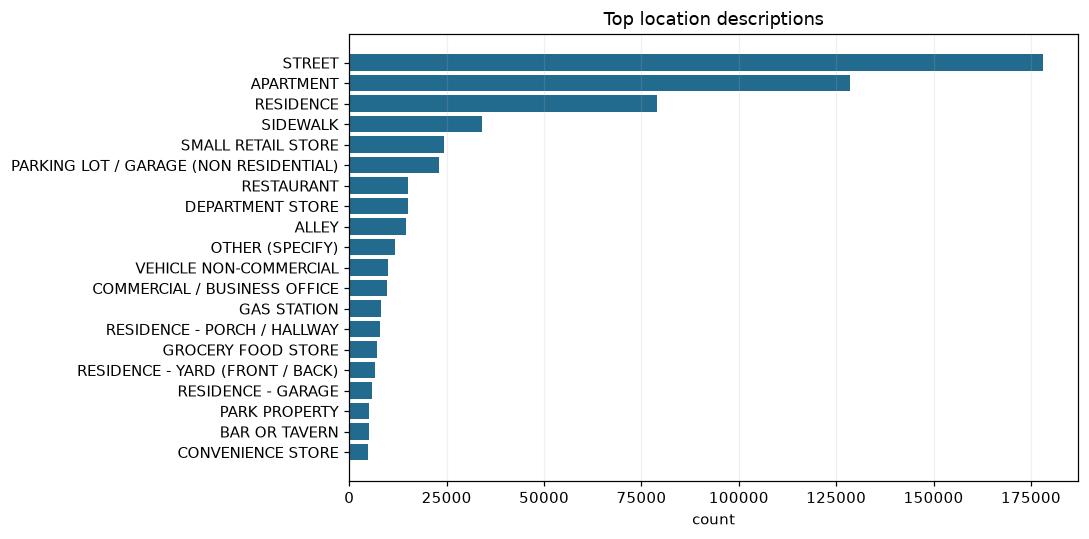

d:\Projects\Chicago_Crime_Prediction\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,group,primary_type,count,within_group_pct
0,9,BATTERY,4441,16.200343
1,7,DECEPTIVE PRACTICE,778,4.567336
2,10,SEX OFFENSE,160,0.560577
3,1,CONCEALED CARRY LICENSE VIOLATION,39,0.178164
4,17,OFFENSE INVOLVING CHILDREN,252,0.711161
...,...,...,...,...
695,13,OTHER NARCOTIC VIOLATION,1,0.003321
696,6,LIQUOR LAW VIOLATION,1,0.007599
697,9,GAMBLING,1,0.003648
698,23,NON-CRIMINAL,1,0.003841


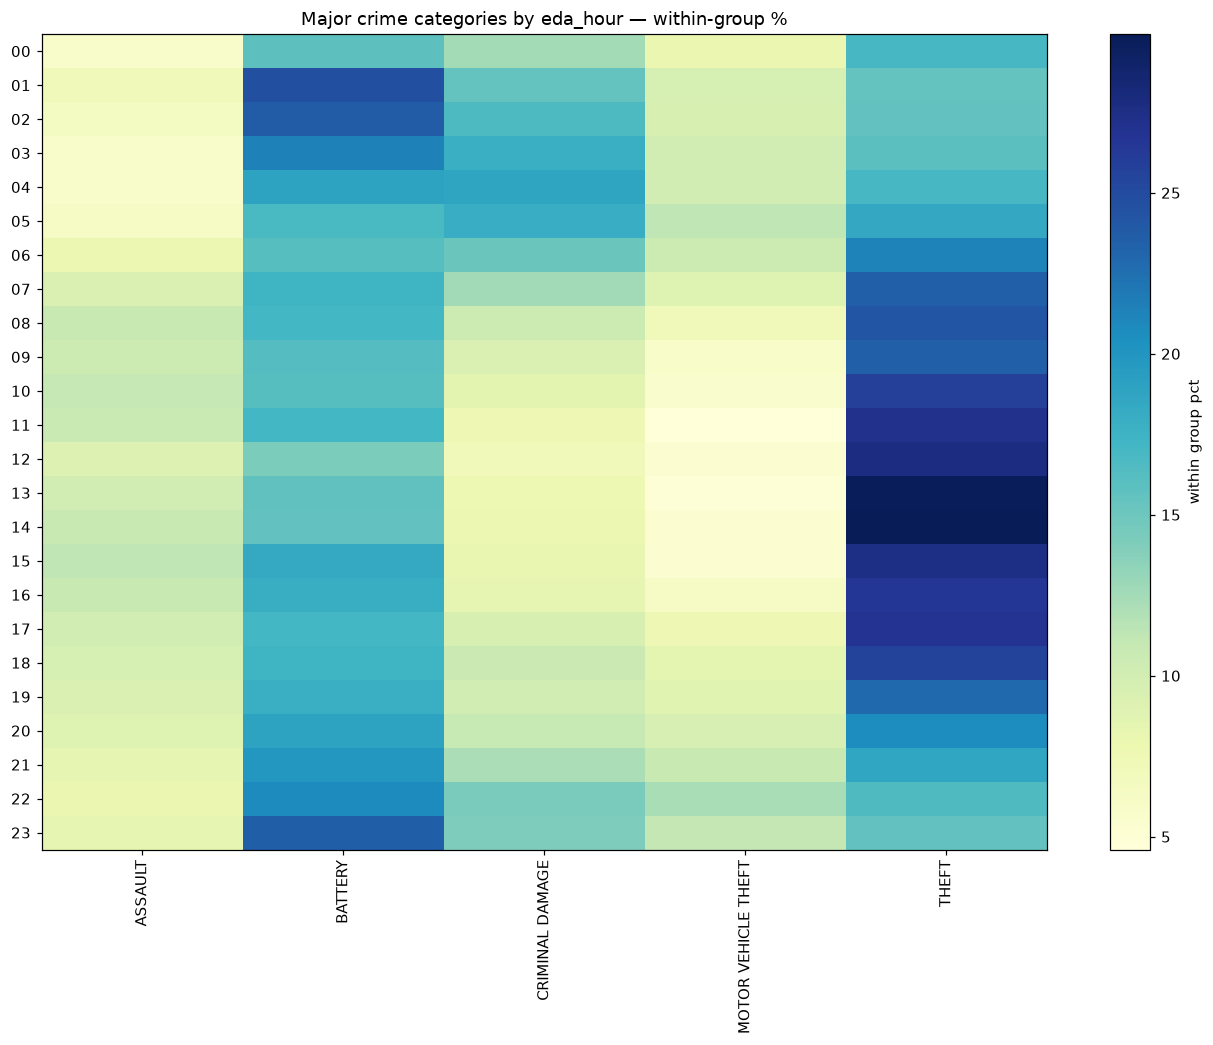

d:\Projects\Chicago_Crime_Prediction\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,group,primary_type,count,within_group_pct
0,1,CONCEALED CARRY LICENSE VIOLATION,74,0.079300
1,5,ARSON,163,0.169442
2,1,STALKING,229,0.245403
3,3,SEX OFFENSE,543,0.585982
4,6,CRIMINAL DAMAGE,11224,11.922288
...,...,...,...,...
209,5,HUMAN TRAFFICKING,7,0.007277
210,6,PUBLIC INDECENCY,6,0.006373
211,3,OTHER NARCOTIC VIOLATION,2,0.002158
212,2,NON-CRIMINAL,1,0.001069


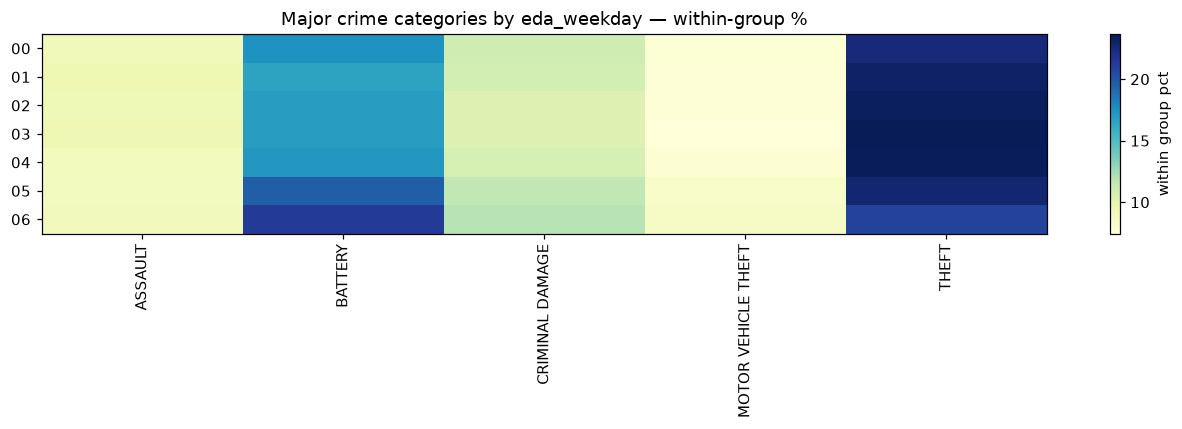

d:\Projects\Chicago_Crime_Prediction\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,group,primary_type,count,within_group_pct
0,7,DECEPTIVE PRACTICE,3944,5.793099
1,9,BATTERY,9848,18.492160
2,10,SEX OFFENSE,223,0.511820
3,1,CONCEALED CARRY LICENSE VIOLATION,50,0.090413
4,5,ARSON,108,0.166839
...,...,...,...,...
356,9,PUBLIC INDECENCY,1,0.001878
357,5,HUMAN TRAFFICKING,6,0.009269
358,4,OTHER NARCOTIC VIOLATION,1,0.001684
359,8,PUBLIC INDECENCY,1,0.001536


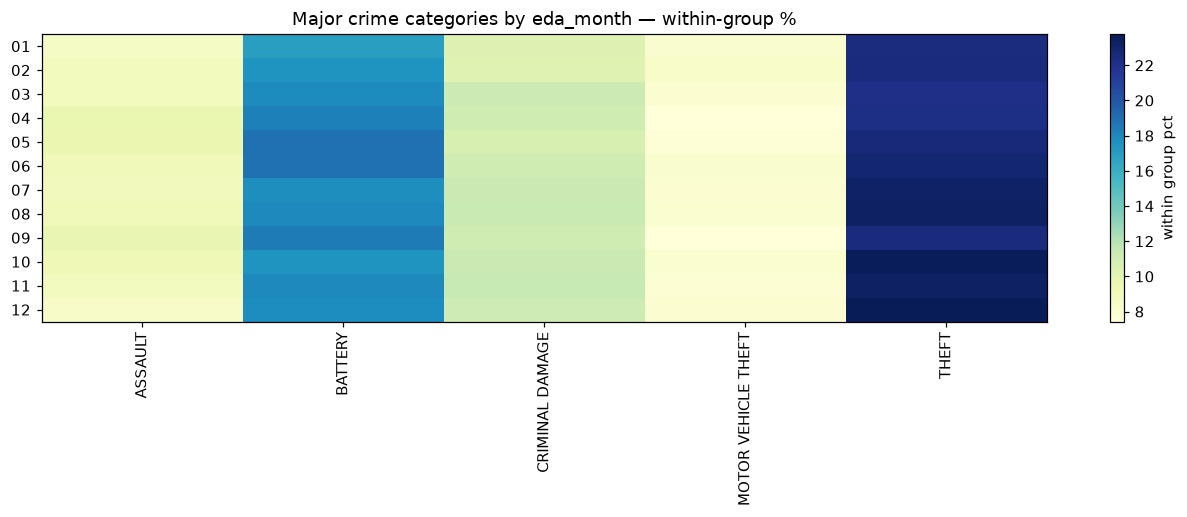

d:\Projects\Chicago_Crime_Prediction\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,group,primary_type,count,within_group_pct
0,61,OFFENSE INVOLVING CHILDREN,148,16.462736
1,14,KIDNAPPING,6,0.024979
2,17,PROSTITUTION,26,0.129987
3,9,BATTERY,5777,19.481352
4,7,DECEPTIVE PRACTICE,1001,3.600201
...,...,...,...,...
660,9,GAMBLING,1,0.003372
661,22,OTHER NARCOTIC VIOLATION,1,0.004856
662,16,HUMAN TRAFFICKING,1,0.004414
663,20,GAMBLING,1,0.007073


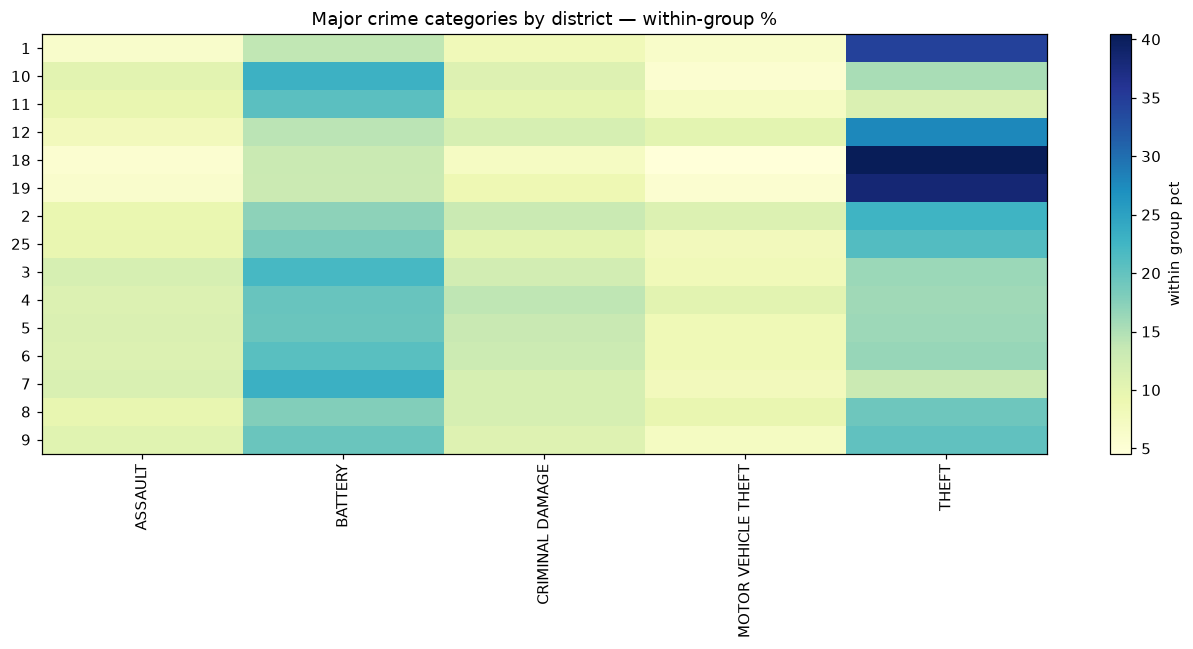

d:\Projects\Chicago_Crime_Prediction\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,group,primary_type,count,within_group_pct
0,60,THEFT,1051,23.402360
1,61,OFFENSE INVOLVING CHILDREN,92,0.887260
2,54,CRIMINAL TRESPASS,41,1.329442
3,59,ROBBERY,79,2.964353
4,43,PUBLIC PEACE VIOLATION,52,0.230588
...,...,...,...,...
2009,44,GAMBLING,1,0.006747
2010,9,ARSON,1,0.145560
2011,65,INTIMIDATION,1,0.020227
2012,67,HUMAN TRAFFICKING,1,0.008326


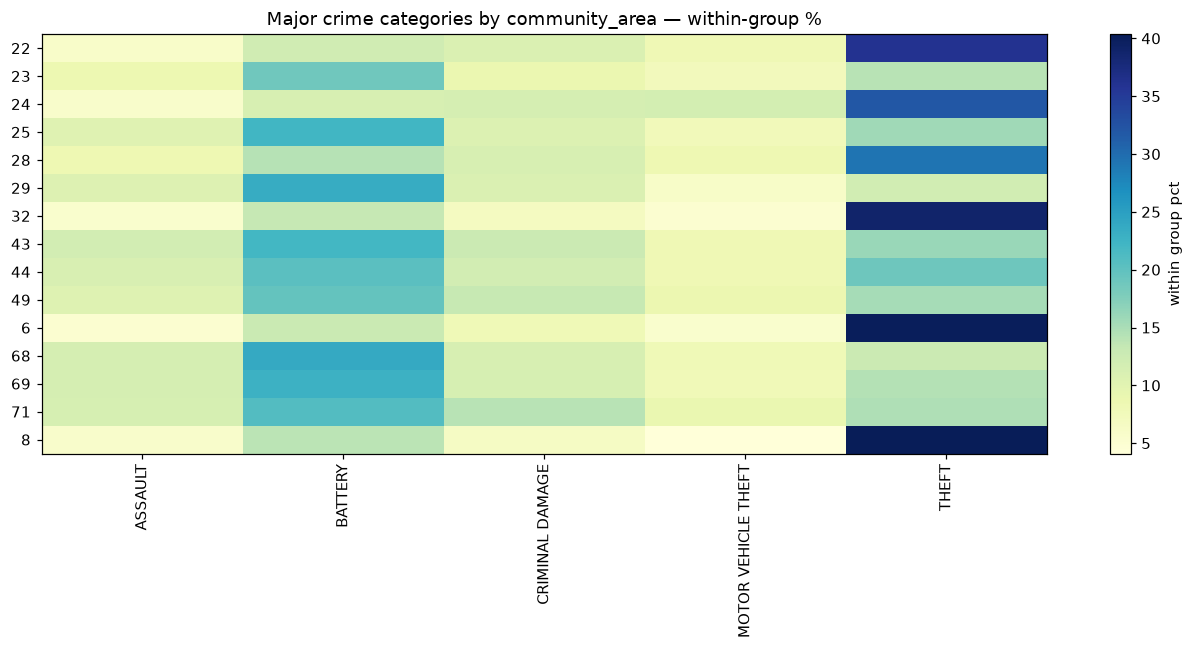

d:\Projects\Chicago_Crime_Prediction\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,group,primary_type,count,within_group_pct
0,GOVERNMENT BUILDING / PROPERTY,THEFT,177,13.937008
1,DRIVEWAY - RESIDENTIAL,BATTERY,89,4.597107
2,DEPARTMENT STORE,PUBLIC PEACE VIOLATION,13,0.086869
3,HIGHWAY / EXPRESSWAY,THEFT,8,6.153846
4,ALLEY,DECEPTIVE PRACTICE,66,0.450666
...,...,...,...,...
1787,CLEANING STORE,OFFENSE INVOLVING CHILDREN,1,0.421941
1788,FIRE STATION,OTHER OFFENSE,1,1.086957
1789,AIRPORT BUILDING NON-TERMINAL - SECURE AREA,WEAPONS VIOLATION,1,0.740741
1790,PARKING LOT / GARAGE (NON RESIDENTIAL),GAMBLING,1,0.004326


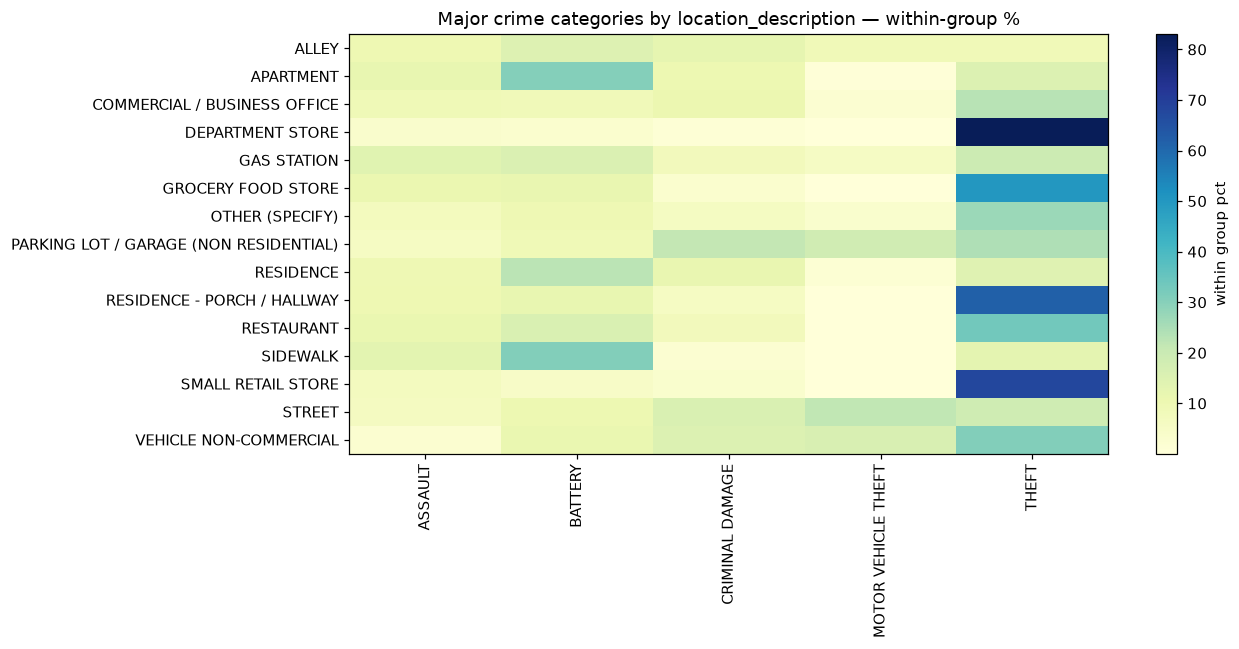

d:\Projects\Chicago_Crime_Prediction\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,group,primary_type,count,within_group_pct
0,false,PROSTITUTION,598,0.111233
1,false,SEX OFFENSE,2906,0.540542
2,true,STALKING,729,0.583840
3,false,PUBLIC PEACE VIOLATION,2895,0.538495
4,false,INTERFERENCE WITH PUBLIC OFFICER,2300,0.427820
5,true,CRIMINAL SEXUAL ASSAULT,933,0.747219
6,true,BURGLARY,840,0.672737
7,true,CRIMINAL TRESPASS,1106,0.885771
8,false,THEFT,143836,26.754760
9,true,ASSAULT,16923,13.553254


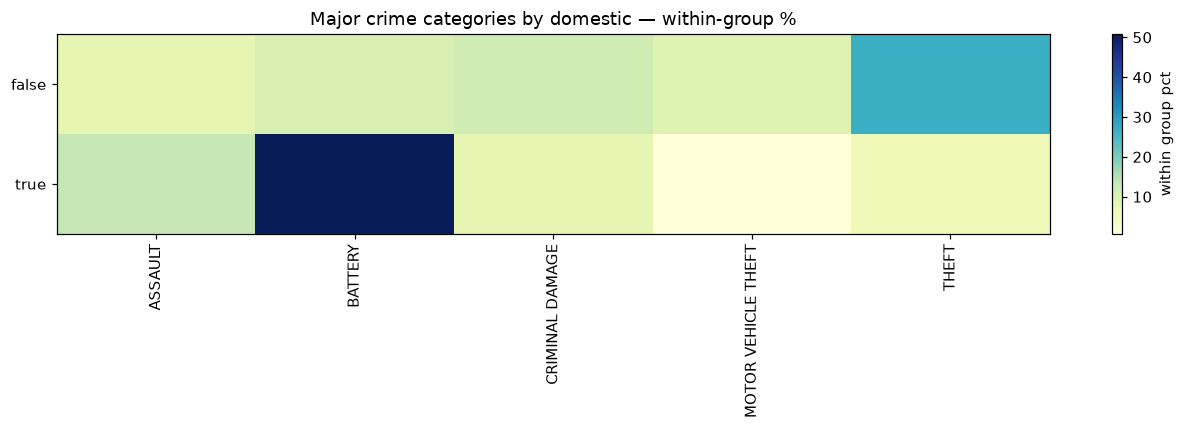

In [33]:
locations = (eda.groupBy(F.coalesce("location_description", F.lit("[MISSING]")).alias("location_description"))
             .count().toPandas().sort_values("count", ascending=False))
table("location_description_counts", locations)
bars("10_location_description", locations, "location_description", title="Top location descriptions", top=20)
note("Location context", f"{len(locations)} location groups including missing, led by {locations.iloc[0].location_description} ({locations.iloc[0]['count']:,} records).",
     "Evaluate location description with explicit missing/unseen handling; learn rare-category grouping on training data.",
     "Context pattern; location description differs from the leakage-prone crime description field.")

cross_summaries = []
for field in ("eda_hour", "eda_weekday", "eda_month", "district", "community_area", "location_description", "domestic"):
    group = F.coalesce(F.col(field).cast("string"), F.lit("[MISSING]"))
    cross = eda.groupBy(group.alias("group"), "primary_type").count().toPandas()
    totals = cross.groupby("group")["count"].sum().sort_values(ascending=False)
    cross["within_group_pct"] = cross["count"] / cross["group"].map(totals) * 100
    table("crime_type_by_" + field, cross)
    keep = totals.head(15).index if field in ("district", "community_area", "location_description") else totals.index
    view = cross[cross.primary_type.isin(TOP_TYPES) & cross["group"].isin(keep)].copy()
    if field.startswith("eda_"):
        view["group"] = view["group"].str.zfill(2)
    heatmap("11_type_by_" + field, view, "group", "primary_type", "within_group_pct", f"Major crime categories by {field} — within-group %")
    maximum = view.loc[view.within_group_pct.idxmax()]
    cross_summaries.append(f"{field}: {maximum.primary_type} reaches {maximum.within_group_pct:.1f}% in displayed group {maximum['group']}")
    note("Crime category by " + field, cross_summaries[-1] + ". Full count and percentage table is exported.",
         "Use differences as feature hypotheses, then verify incremental value on validation data. Check each group's support before interpreting percentages.",
         "Association does not establish causation or predictive value. Domestic must be available at the intended prediction time; no post-event fields should leak the answer.")

### Unusual daily totals and sparse groups
The 1.5×IQR rule is an exploratory flag, not a deletion rule. Include calendar zeroes and
distinguish boundary days. Investigate flagged dates with Member 1 before changing data.

d:\Projects\Chicago_Crime_Prediction\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,day,count,flag_iqr,boundary_day
0,2024-01-01,1052,True,True
1,2024-01-02,656,False,False
2,2024-01-03,678,False,False
3,2024-01-04,693,False,False
4,2024-01-05,682,False,False
...,...,...,...,...
985,2026-09-12,701,False,False
986,2026-09-13,660,False,False
987,2026-09-14,561,False,False
988,2026-09-15,617,False,False


,day,count,flag_iqr,boundary_day
0,2024-01-01,1052,True,True
13,2024-01-14,401,True,False
121,2024-05-01,864,True,False
152,2024-06-01,900,True,False
186,2024-07-05,879,True,False
244,2024-09-01,948,True,False
305,2024-11-01,905,True,False
332,2024-11-28,418,True,False
366,2025-01-01,902,True,False
408,2025-02-12,464,True,False


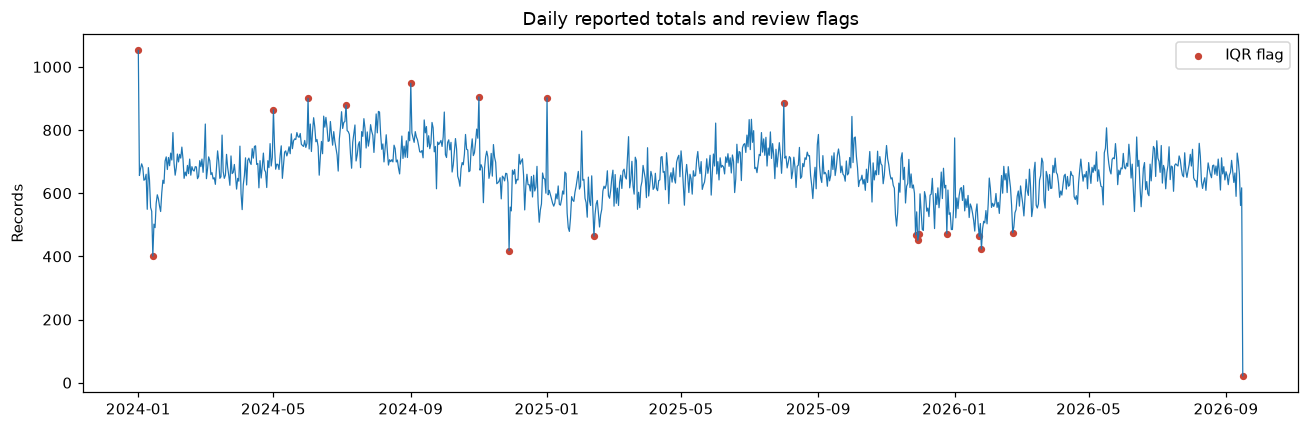

,feature,groups_below_100,total_groups
0,district,1,24
1,community_area,0,78
2,ward,0,51
3,beat,1,276


In [34]:
daily = eda.groupBy("eda_day").count().toPandas()
daily["day"] = pd.to_datetime(daily.eda_day)
daily = calendar[["day"]].merge(daily[["day", "count"]], on="day", how="left").fillna({"count": 0})
q1, q3 = daily["count"].quantile([.25, .75])
iqr = q3 - q1
daily["flag_iqr"] = (daily["count"] < q1 - 1.5 * iqr) | (daily["count"] > q3 + 1.5 * iqr)
daily["boundary_day"] = daily.day.isin([START.normalize(), END.normalize()])
table("daily_counts_and_flags", daily)
table("unusual_daily_totals", daily[daily.flag_iqr | (daily["count"] == 0)])
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily.day, daily["count"], linewidth=.8)
flagged = daily[daily.flag_iqr]
ax.scatter(flagged.day, flagged["count"], color="#c84536", s=14, label="IQR flag")
ax.set(title="Daily reported totals and review flags", ylabel="Records")
ax.legend()
savefig("12_daily_review", fig)
sparse = pd.DataFrame([{"feature": f, "groups_below_100": int((t["count"] < 100).sum()), "total_groups": len(t)} for f, t in geography.items()])
table("sparse_geographic_groups", sparse)
note("Unusual observations", f"{len(flagged)} dates are flagged by the IQR rule; {int((daily['count']==0).sum())} calendar days have zero records. IQR = {iqr:.1f}.",
     "Investigate extract gaps, revisions, holidays or rounded timestamps; do not remove records solely because a count is unusual.",
     "Potential outliers; this pooled rule does not adjust for weekday, seasonality or long-term trend.")

### Optional Member 3 City Zone / Area Group validation
Supply `features_table` to enable this step. Join by the record identifier, never row order.
Require a one-to-one, complete match. Obtain Member 3's documented mapping and construction
rule before interpreting the group. This notebook does not invent geographic boundaries.

In [35]:
zone_status = "Pending Member 3: no features_table supplied."
if FEATURES_TABLE:
    features = spark.table(FEATURES_TABLE)
    zone_candidates = [c for c in features.columns if c.lower() in ("city_zone", "area_group")]
    if "unique_key" not in features.columns or not zone_candidates:
        raise ValueError("Feature table needs unique_key plus City_Zone or Area_Group (case-insensitive).")
    zone_col = zone_candidates[0]
    for label, source in [("clean", eda), ("features", features)]:
        if source.filter(F.col("unique_key").isNull()).limit(1).count() or source.groupBy("unique_key").count().filter("count > 1").limit(1).count():
            raise ValueError(f"{label} unique_key must be non-null and unique for the zone join.")
    if eda.join(features, "unique_key", "left_anti").limit(1).count() or features.join(eda, "unique_key", "left_anti").limit(1).count():
        raise ValueError("Feature table and cleaned table must contain the same incident IDs.")
    zone = eda.select("unique_key", "primary_type").join(features.select("unique_key", F.col(zone_col).alias("member3_zone")), "unique_key")
    z = zone.groupBy(F.coalesce(F.col("member3_zone").cast("string"), F.lit("[MISSING]")).alias("zone"), "primary_type").count().toPandas()
    z["within_zone_pct"] = z["count"] / z.groupby("zone")["count"].transform("sum") * 100
    table("crime_type_by_city_zone", z)
    ztotals = z.groupby("zone", as_index=False)["count"].sum().sort_values("count", ascending=False)
    table("city_zone_counts", ztotals)
    bars("13_city_zone", ztotals, "zone", title="Member 3 geographic group counts", top=25)
    note("City Zone counts", f"{len(ztotals)} groups including missing; chart displays at most 25.",
         "Check Member 3's mapping, missingness, and group support before accepting the feature.", "Engineered geography; count differences do not validate boundaries.")
    heatmap("14_type_by_city_zone", z[z.primary_type.isin(TOP_TYPES) & z.zone.isin(ztotals.head(25).zone)], "zone", "primary_type", "within_zone_pct", "Crime category mix by Member 3 geographic group")
    zone_status = f"Analysed {FEATURES_TABLE}.{zone_col}; {len(ztotals)} groups. Mapping rationale and model ablation remain for Member 3/4."
    note("City Zone category mix", zone_status, "Compare validation performance with and without the engineered feature; fit any clustering on training data only.", "EDA association alone does not prove added predictive value.")
else:
    displayHTML("<p>" + html.escape(zone_status) + " Rerun with the feature table when available.</p>")

## 4. Findings / conclusion and report evidence
The following ten findings are generated from this run. The bundle includes every chart in
PNG and SVG, aggregate CSVs, chart interpretations, provenance, and a Member 3/4 handover.
Download the ZIP from the final link. Large row-level incident data are never exported.

In [36]:
findings = [
    f"Coverage: {N:,} cleaned incident records, {len(df.columns)} source columns, {START} through {END}. Partial periods need explicit exposure controls.",
    f"Class imbalance: {major.primary_type} represents {major.share_pct:.2f}% of records; {minor.primary_type} has {minor['count']:,}. Use macro/per-class metrics alongside accuracy.",
    f"Sparse targets: {imbalance['classes_below_100']} classes have fewer than 100 records; top five classes account for {imbalance['top_5_share_pct']:.2f}%. Preserve class support in evaluation.",
    f"Temporal coverage: matched comparisons use {lower_md} inclusive to {upper_md} exclusive. Avoid interpreting a partial year's lower total as a decline.",
    f"Monthly/hourly structure: peak observed month {peak_month.month}; peak recorded hour {peak_hour:02d}:00. Check partial months and default times before modelling.",
    f"Weekday structure: largest total on {week.loc[week['count'].idxmax(), 'weekday']}; weekday_counts.csv includes calendar-day-normalized exposure.",
    "Geographic structure: " + "; ".join(f"largest {f} group {t.iloc[0][f]} ({t.iloc[0]['count']:,})" for f, t in geography.items()) + ". Counts are not population-adjusted rates.",
    f"Coordinate coverage: {mapped:,} records ({mapped/N*100:.2f}%) plotted; {N-mapped:,} omitted from the coordinate plot only. Review class-specific missingness before imputation.",
    f"Context: leading location group {locations.iloc[0].location_description}. Category-mix tables cover time, geography, location and domestic status; verify associations on validation data.",
    f"Review flags: {len(flagged)} unusual daily totals, {int((daily['count']==0).sum())} zero-record days. Investigate rather than automatically delete. City Zone status: {zone_status}",
]
report = "# Member 2 — generated EDA findings\n\n" + "\n\n".join(f"{i}. {text}" for i, text in enumerate(findings, 1))
report += "\n\n## Handover to Member 3\n\nEvaluate temporary time features, categorical geographic codes, location context and missingness. Review sparse groups. Exclude IUCR, crime description and FBI code from ordinary predictors; review arrest, updated_on and any post-event information. Confirm Domestic is known at prediction time. Fit encoders, imputers and any geographic clustering on training data only. Document the City Zone mapping.\n"
report += "\n## Handover to Member 4\n\nAgree a time-aware train/validation/test protocol, retain support counts, and compare a training-majority baseline with models on the same evaluation population. Report accuracy, macro precision/recall/F1, weighted F1 and per-class results. Do not tune on the final test set. Use validation ablations to assess feature value.\n"
report += "\n## Limitations\n\nThese are associations in reported incidents, subject to reporting/enforcement patterns and extract coverage. They do not establish causality, future incident risk, or characteristics of individuals. No population denominators are available. City Zone EDA cannot establish model improvement.\n"
(OUT / "member2_findings_and_handover.md").write_text(report, encoding="utf-8")
interpretations = "# Chart interpretations\n\n" + "\n\n".join(f"## {n['title']}\n\nWhat it shows: {n['observation']}\n\nWhy it matters: {n['implication']}\n\nPattern / limitation: {n['signal']}" for n in NOTES)
(OUT / "chart_interpretations.md").write_text(interpretations, encoding="utf-8")
manifest = {"run_id": RUN_ID, "clean_table": CLEAN_TABLE, "source_delta_version": globals().get("SOURCE_VERSION", 1), "features_table": FEATURES_TABLE,
            "spark_version": spark.version, "session_timezone": spark.conf.get("spark.sql.session.timeZone"),
            "observed_metadata": meta, "class_imbalance": imbalance, "zone_status": zone_status,
            "figures": FIGURES, "tables": list(TABLES), "coordinate_grid_degrees": .01,
            "coordinate_screen": {"latitude": [41, 43], "longitude": [-89, -87]},
            "notes": "Source table is read only and pinned to the recorded Delta version."}
(OUT / "run_manifest.json").write_text(json.dumps(manifest, indent=2, default=str), encoding="utf-8")
displayHTML("<h2>Ten EDA findings</h2><ol>" + "".join("<li>" + html.escape(f) + "</li>" for f in findings) + "</ol>")
with tempfile.TemporaryDirectory() as archive_tmp:
    local_archive = shutil.make_archive(str(Path(archive_tmp) / RUN_ID), "zip", root_dir=OUT)
    archive = str(OUT) + ".zip"
    shutil.copyfile(local_archive, archive)
print(f"Evidence folder: {OUT}\nEvidence ZIP: {archive}")
from IPython.display import FileLink
display(FileLink(archive, result_html_prefix="Download evidence ZIP: "))
print("If the compute UI cannot serve this local link, set output_dir to a writable Unity Catalog Volume and download the ZIP using the Catalog file browser.")
if 'dbutils' in globals() and hasattr(dbutils, 'notebook') and hasattr(dbutils.notebook, 'exit'):
    try:
        dbutils.notebook.exit(json.dumps({"status": "SUCCESS", "evidence_directory": str(OUT), "evidence_archive": archive}))
    except Exception:
        pass
print(json.dumps({"status": "SUCCESS", "evidence_directory": str(OUT), "evidence_archive": archive}, indent=2))


Evidence folder: D:\Projects\Chicago_Crime_Prediction\databricks\04_EDA\reports\eda_evidence\20261006T080841Z_5e057ffc
Evidence ZIP: D:\Projects\Chicago_Crime_Prediction\databricks\04_EDA\reports\eda_evidence\20261006T080841Z_5e057ffc.zip


D:\Projects\Chicago_Crime_Prediction\databricks\04_EDA\reports\eda_evidence\20261006T080841Z_5e057ffc.zip

If the compute UI cannot serve this local link, set output_dir to a writable Unity Catalog Volume and download the ZIP using the Catalog file browser.
{
  "status": "SUCCESS",
  "evidence_directory": "D:\\Projects\\Chicago_Crime_Prediction\\databricks\\04_EDA\\reports\\eda_evidence\\20261006T080841Z_5e057ffc",
  "evidence_archive": "D:\\Projects\\Chicago_Crime_Prediction\\databricks\\04_EDA\\reports\\eda_evidence\\20261006T080841Z_5e057ffc.zip"
}
